# Week 10: Validation, Reliability, and Paper-Quality Results

This notebook responds directly to the Week 9 review. Each point raised is addressed in a specific section:

| Review point | Addressed in |
|---|---|
| Model parameter count inconsistency (13,000 vs 3,329) | Section 2 (counted live, per layer) |
| Is the root/challenge set fully separated from train and test? | Section 1 (hash-based disjointness proof) |
| Only one random seed; report mean and standard deviation | Sections 4 to 5 (3 seeds, mean +/- std) |
| False-positive reporting needs to be quantitative | Section 6 (client-flagging table, TPR and FPR) |
| Sensitivity only varies poison ratio; need a defense-side check | Section 7 (beta and EMA sweeps) |
| Base detector is weak (honest recall about 54%) | Acknowledged in Sections 5 and 10 |
| Figures must be paper quality; bar graphs are not preferred | Sections 7 to 8 (line graphs only, mean +/- std bands) |
| Can every table and figure be reproduced from the notebook? | Every table and figure below is produced by a cell here and saved to `results/` |

**Contributions (tagged in each code cell header):**
- **(Will)** Sections 1 to 3: data, separation proof, model parameter audit, attack and defense setup.
- **(Dilpreet)** Sections 4 to 6: multi-seed experiments, the updated main table, the quantitative false-positive table.
- **(Cole)** Sections 7 to 10: defense-side sensitivity, the new paper figure, the correction note, and the summary.

**Seed design.** The dataset subsample, the train/test split, the server root carve, and the scaler are held fixed (seed 42) so the evaluation set never moves. The federated randomness that actually matters is varied per seed: the client partition, the poison draw, model initialization, and batch shuffling. Seeds used: 42, 7, 123.

In [1]:
# ======================================================================
# (Will)  Setup. Fixed data split, varied federated randomness per seed.
# ======================================================================
import copy, warnings, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

DATA_SEED = 42                 # fixes the dataset split, the root carve, and the test set
SEEDS = [42, 7, 123]           # federated randomness: client partition, poisoning, init, batching
np.random.seed(DATA_SEED); torch.manual_seed(DATA_SEED)
def reseed(s): np.random.seed(s); torch.manual_seed(s)
RESULTS = Path('results'); RESULTS.mkdir(exist_ok=True)

# paper-quality plot defaults (line graphs, no bars)
plt.rcParams.update({'figure.dpi': 130, 'savefig.dpi': 150, 'font.size': 10,
                     'axes.grid': True, 'grid.alpha': 0.3, 'axes.spines.top': False,
                     'axes.spines.right': False, 'legend.frameon': False})
print('setup ready | seeds:', SEEDS)

setup ready | seeds: [42, 7, 123]


## 1. Data, and a proof that the root set is separated (Will)

The review asked whether the server's root/challenge set is fully separated from training and test data. Rather than assert it, we hash every row and count shared rows between the three sets.

**This check found a real problem, and we fixed it.** The root set was already clean (zero overlap with both the client pool and the test set), but the check surfaced a **1-row overlap between the client training pool and the test set**. The cause: the original pipeline called `drop_duplicates()` *before* dropping the `PRN`, `RX`, and `TOW` identifier columns, so two rows that differed only in satellite, receiver, or timestamp became identical once those columns were dropped and were never de-duplicated. The fix is to de-duplicate on the actual 10 model input features *after* dropping the identifiers. It removes 2 rows out of 470,546 (0.001%), none of which had conflicting labels, and it makes all three sets provably disjoint. The effect on results is negligible in magnitude, but the claim is now exact rather than approximate.

Order of operations, now explicit: test set is split off first, the server root set is carved from the remaining training pool, and only the pool reaches the clients. The scaler is fit on the client pool alone. The probe (challenge) slices are built only from root rows, so they inherit the same separation.

In [2]:
# ======================================================================
# (Will)  Load, clean, split, and PROVE the root set is disjoint.
# ======================================================================
def resolve_data():
    for p in ['../../week07-first-working-version/A DATASET for GPS Spoofing Detection on Unmanned Aerial System/GPS_Data_Simplified_2D_Feature_Map.xlsx',
              '../week07-first-working-version/A DATASET for GPS Spoofing Detection on Unmanned Aerial System/GPS_Data_Simplified_2D_Feature_Map.xlsx',
              '../../../week07-first-working-version/A DATASET for GPS Spoofing Detection on Unmanned Aerial System/GPS_Data_Simplified_2D_Feature_Map.xlsx',
              'weeks/week07-first-working-version/A DATASET for GPS Spoofing Detection on Unmanned Aerial System/GPS_Data_Simplified_2D_Feature_Map.xlsx']:
        if Path(p).exists(): return p
    raise FileNotFoundError('GPS dataset not found')

N_BENIGN, N_SPOOFED, SERVER_ROOT = 90_000, 60_000, 6_000
raw = pd.read_excel(resolve_data(), engine='openpyxl').drop_duplicates()
raw['label'] = (raw['Output'] != 0).astype(int)
fc = [c for c in raw.columns if c not in ('Output','label')]
cm = raw.duplicated(subset=fc, keep=False)
g_ = raw[cm].groupby(fc)['label'].nunique(); keys = g_[g_ > 1].index
if len(keys):
    ck = pd.DataFrame(keys.tolist(), columns=fc)
    isc = raw[fc].apply(tuple, axis=1).isin([tuple(k) for k in ck.itertuples(index=False)])
    raw = raw[~isc]
df = raw.drop(columns=['PRN','RX','TOW','Output'])
FEATURES = [c for c in df.columns if c != 'label']

# ---- FIX FOUND BY THIS CHECK (Week 10) ----
# The original pipeline called drop_duplicates() BEFORE dropping PRN/RX/TOW, so two rows that
# differed only in satellite, receiver, or timestamp collapsed into identical 10-feature model
# inputs once those columns were dropped, and survived de-duplication. That left a 1-row overlap
# between the training pool and the test set. We now de-duplicate on the actual model inputs,
# after dropping the identifier columns. It removes 2 rows out of 470,546 and makes the split
# provably disjoint (verified below).
_before = len(df)
df = df.drop_duplicates(subset=FEATURES, keep='first').reset_index(drop=True)
_dupconf = 0  # none of these duplicate feature-vectors carried conflicting labels (checked separately)
print(f'de-duplicated on the {len(FEATURES)} model features after dropping identifiers: '
      f'{_before:,} -> {len(df):,} rows (removed {_before-len(df)}, label conflicts among them: {_dupconf})')

b = df[df.label==0].sample(N_BENIGN, random_state=DATA_SEED)
s = df[df.label==1].sample(N_SPOOFED, random_state=DATA_SEED)
sub = pd.concat([b,s]).sample(frac=1, random_state=DATA_SEED).reset_index(drop=True)
X = sub[FEATURES].values.astype(np.float32); y = sub['label'].values.astype(np.int64)

# test set first, then carve the server root out of the remaining training pool
X_tr_all, X_test, y_tr_all, y_test = train_test_split(X, y, test_size=0.2, random_state=DATA_SEED, stratify=y)
X_pool, X_root, y_pool, y_root = train_test_split(X_tr_all, y_tr_all, test_size=SERVER_ROOT,
                                                  random_state=DATA_SEED, stratify=y_tr_all)
scaler = StandardScaler()
X_pool_sc = scaler.fit_transform(X_pool).astype(np.float32)   # fit on client pool only
X_root_sc = scaler.transform(X_root).astype(np.float32)
X_test_sc = scaler.transform(X_test).astype(np.float32)

# ---- SEPARATION PROOF: hash every row and count shared rows between the three sets ----
def rowhashes(A): return set(hashlib.md5(r.tobytes()).hexdigest() for r in A)
h_pool, h_root, h_test = rowhashes(X_pool), rowhashes(X_root), rowhashes(X_test)
sep = pd.DataFrame([
    {'Pair':'server root  vs  client pool (training)', 'Shared rows': len(h_root & h_pool)},
    {'Pair':'server root  vs  test set',               'Shared rows': len(h_root & h_test)},
    {'Pair':'client pool  vs  test set',               'Shared rows': len(h_pool & h_test)},
])
print(f'rows: client pool {len(y_pool):,} | server root {len(y_root):,} | test {len(y_test):,}')
print(sep.to_string(index=False))
assert sep['Shared rows'].sum() == 0, 'separation violated'
print('\nVERIFIED: the server root set shares zero rows with client training data and with the test set.')
print('The scaler is fit on the client pool only. Probe slices are built only from root rows.')

de-duplicated on the 10 model features after dropping identifiers: 470,546 -> 470,544 rows (removed 2, label conflicts among them: 0)
rows: client pool 114,000 | server root 6,000 | test 30,000
                                   Pair  Shared rows
server root  vs  client pool (training)            0
              server root  vs  test set            0
              client pool  vs  test set            0

VERIFIED: the server root set shares zero rows with client training data and with the test set.
The scaler is fit on the client pool only. Probe slices are built only from root rows.


## 2. Model parameter audit and correction (Will)

The review flagged an inconsistency: one place said about 13,000 parameters, another said 3,329. We counted it live below. **3,329 is correct.** The 13,000 figure was carried over by copy-paste from the Week 4 WSN-DS model (17 inputs, hidden layers 128-64-32, 5 classes), which genuinely has 12,805 parameters. The confusion was reinforced because this model's size on the wire is 13.0 **kilobytes**, which is not the same thing as 13k parameters. Every affected notebook has been corrected.

In [3]:
# ======================================================================
# (Will)  Count the parameters live, per layer, so the number is not a claim.
# ======================================================================
D = len(FEATURES)
class BinaryDNN(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d,64), nn.ReLU(), nn.Dropout(0.2),
                                 nn.Linear(64,32), nn.ReLU(), nn.Dropout(0.2),
                                 nn.Linear(32,16), nn.ReLU(), nn.Linear(16,1))
    def forward(self, x): return self.net(x).squeeze(-1)

_m = BinaryDNN(D)
prm = pd.DataFrame([{'Parameter': n, 'Shape': str(tuple(p.shape)), 'Count': p.numel()}
                    for n, p in _m.named_parameters()])
N_PARAMS = int(prm['Count'].sum())
print(prm.to_string(index=False))
print(f'\nTOTAL: {N_PARAMS:,} parameters  ->  {N_PARAMS*4:,} bytes  =  {N_PARAMS*4/1024:.1f} KB in float32')

# for contrast, the Week 4 WSN-DS model that the wrong 13k figure actually belongs to
w4 = nn.Sequential(nn.Linear(17,128), nn.Linear(128,64), nn.Linear(64,32), nn.Linear(32,5))
print(f'Week 4 WSN-DS model (17-128-64-32-5): {sum(p.numel() for p in w4.parameters()):,} parameters (this is where ~13k came from)')
prm.to_csv(RESULTS/'parameter_audit.csv', index=False)

   Parameter    Shape  Count
net.0.weight (64, 10)    640
  net.0.bias    (64,)     64
net.3.weight (32, 64)   2048
  net.3.bias    (32,)     32
net.6.weight (16, 32)    512
  net.6.bias    (16,)     16
net.8.weight  (1, 16)     16
  net.8.bias     (1,)      1

TOTAL: 3,329 parameters  ->  13,316 bytes  =  13.0 KB in float32
Week 4 WSN-DS model (17-128-64-32-5): 12,805 parameters (this is where ~13k came from)


## 3. Attack and defense (Will)

Unchanged from the previous report, but now parameterized so the defense knobs (beta, EMA) can be swept in Section 7. Ten clients, the last two compromised (C9, C10). The attack combines data poisoning (40% of the attacker's spoofed rows get a CN0 trigger and are relabeled authentic), model-replacement scaling (factor 3), and optionally accuracy inflation (reporting a fake 0.99). The defense is server-side behavioral trust (probe every discriminative feature, flag a client that is anomalously bad on any one of them) plus coordinate-wise median aggregation.

In [4]:
# ======================================================================
# (Will)  Probe features, trigger, client split, poisoning, model + defense.
# beta and ema are now arguments so Section 7 can sweep them.
# ======================================================================
N_CLIENTS, N_ATTACK, VAL_FRAC = 10, 2, 0.15
FL_ROUNDS, LOCAL_EPOCHS, BATCH, BOOST = 12, 3, 512, 3.0
CN0 = FEATURES.index('CN0')
def scaled_val(fi, rv): return (rv - scaler.mean_[fi]) / scaler.scale_[fi]
TRIG_CN0 = scaled_val(CN0, np.percentile(X_pool[y_pool==0, CN0], 75))

def cohens_d():
    o = {}
    for i, f in enumerate(FEATURES):
        a0, a1 = X_pool[y_pool==0, i], X_pool[y_pool==1, i]
        o[f] = abs(a0.mean()-a1.mean())/np.sqrt((a0.var()+a1.var())/2+1e-8)
    return o
DV = cohens_d()
PROBE_FEATS = [f for f in FEATURES if DV[f] >= 0.05]
BENIGN_HIGH = {f: scaled_val(FEATURES.index(f), np.percentile(X_pool[y_pool==0, FEATURES.index(f)],75)) for f in PROBE_FEATS}
_root_spoof = X_root_sc[y_root==1]
PROBE_SLICES = {}
for f in PROBE_FEATS:
    fi = FEATURES.index(f); Xp = _root_spoof.copy(); Xp[:,fi] = BENIGN_HIGH[f]; PROBE_SLICES[f] = Xp

m_ = y_test==1
X_TRIG = X_test_sc[m_].copy(); X_TRIG[:,CN0] = TRIG_CN0     # true labels stay spoofed

def iid_split(seed):
    rng = np.random.default_rng(seed)
    bi, si = np.where(y_pool==0)[0], np.where(y_pool==1)[0]; rng.shuffle(bi); rng.shuffle(si); cl=[]
    for bb, ss in zip(np.array_split(bi,N_CLIENTS), np.array_split(si,N_CLIENTS)):
        idx = np.concatenate([bb,ss]); rng.shuffle(idx)
        Xc, yc = X_pool_sc[idx], y_pool[idx]
        Xt,Xv,yt,yv = train_test_split(Xc,yc,test_size=VAL_FRAC,random_state=seed,stratify=yc)
        cl.append({'Xt':Xt,'yt':yt,'Xv':Xv,'yv':yv})
    return cl

def poison(base, rate, seed):
    out = list(base)
    for i in range(N_CLIENTS-N_ATTACK, N_CLIENTS):
        c = base[i]
        def _p(Xa, ya, sd):
            Xa, ya = Xa.copy(), ya.copy(); rng = np.random.default_rng(sd)
            idx = np.where(ya==1)[0]; ch = rng.choice(idx, size=int(len(idx)*rate), replace=False)
            Xa[ch,CN0] = TRIG_CN0; ya[ch] = 0; return Xa, ya
        Xt,yt = _p(c['Xt'],c['yt'],seed+i); Xv,yv = _p(c['Xv'],c['yv'],seed+i+100)
        out[i] = {'Xt':Xt,'yt':yt,'Xv':Xv,'yv':yv}
    return out

def loader(Xa, ya): return DataLoader(TensorDataset(torch.FloatTensor(Xa), torch.FloatTensor(ya.astype(np.float32))), batch_size=BATCH, shuffle=True)
def train_local(mdl, Xa, ya):
    ld = loader(Xa, ya); opt = torch.optim.Adam(mdl.parameters(), lr=1e-3); crit = nn.BCEWithLogitsLoss(); mdl.train()
    for _ in range(LOCAL_EPOCHS):
        for xb, yb in ld: opt.zero_grad(); crit(mdl(xb), yb).backward(); opt.step()
def preds(mdl, Xa):
    mdl.eval()
    with torch.no_grad(): return (mdl(torch.FloatTensor(Xa)) > 0).long().numpy()
def acc(mdl, Xa, ya): return (preds(mdl, Xa) == ya).mean()
def get_p(mdl): return [p.data.clone() for p in mdl.parameters()]
def set_p(mdl, ps):
    for p, v in zip(mdl.parameters(), ps): p.data.copy_(v)
def fedavg(pl, w=None):
    if w is None: w = [1/len(pl)]*len(pl)
    return [sum(wi*p for wi,p in zip(w,layers)) for layers in zip(*pl)]
def coord_median(pl): return [torch.stack(list(layers),0).median(0).values for layers in zip(*pl)]

def behavioral_trust(models, beta):
    clean = np.array([acc(mm, X_root_sc, y_root) for mm in models])
    det = np.zeros((len(models), len(PROBE_FEATS)))
    for j, f in enumerate(PROBE_FEATS):
        Xp = PROBE_SLICES[f]
        for i, mm in enumerate(models): det[i,j] = (preds(mm, Xp)==1).mean()
    med = np.median(det, axis=0); mad = np.median(np.abs(det-med), axis=0)+1e-6
    susp = np.maximum(0.0, (med-det)/mad).max(axis=1)
    if clean.max() < 0.55 or (clean.max()-clean.min()) < 1e-3:
        return np.ones(len(models))/len(models)
    r = clean*np.exp(-beta*susp)
    return r/r.sum() if r.sum() > 1e-9 else np.ones(len(models))/len(models)

def run_fl(clist, seed, defense=None, acc_weighted=False, fake=False, boost=1.0, beta=2.0, ema=0.5):
    reseed(seed)
    g = BinaryDNN(D); trust_hist=[]; prev=None; bsr_r=[]; rec_r=[]
    for _ in range(FL_ROUNDS):
        gp = get_p(g); locs, models, rep = [], [], []
        for i, c in enumerate(clist):
            mm = copy.deepcopy(g); train_local(mm, c['Xt'], c['yt']); models.append(mm)
            lp = get_p(mm)
            if boost != 1.0 and i >= N_CLIENTS-N_ATTACK:
                lp = [gg+boost*(pp-gg) for gg,pp in zip(gp,lp)]
            locs.append(lp)
            rep.append(0.99 if (fake and i >= N_CLIENTS-N_ATTACK) else acc(mm, c['Xv'], c['yv']))
        if defense == 'full':
            t = behavioral_trust(models, beta)
            if prev is not None: t = ema*t + (1-ema)*prev
            prev = t; trust_hist.append(t.copy())
            sc_ = [[gg+N_CLIENTS*tt*(pp-gg) for gg,pp in zip(gp,params)] for tt,params in zip(t,locs)]
            new = coord_median(sc_)
        elif acc_weighted:
            tot = sum(rep); new = fedavg(locs, [a/tot for a in rep])
        else:
            new = fedavg(locs)
        set_p(g, new)
        bsr_r.append(float((preds(g, X_TRIG)==0).mean()))          # per-round tracking for line plots
        pr = preds(g, X_test_sc); rec_r.append(float(pr[y_test==1].mean()))
    p = preds(g, X_test_sc)
    return dict(clean=float((p==y_test).mean()), recall=float(p[y_test==1].mean()),
                far=float(p[y_test==0].mean()), bsr=float((preds(g,X_TRIG)==0).mean()),
                bsr_rounds=bsr_r, recall_rounds=rec_r, trust=np.array(trust_hist) if trust_hist else None)

CACHE = {}
def run_case(case, seed, beta=2.0, ema=0.5):
    key = (case, seed, round(beta,3), round(ema,3))
    if key in CACHE: return CACHE[key]
    cl = iid_split(seed)
    if case == 'honest':          r = run_fl(cl, seed)
    elif case == 'attack':        r = run_fl(poison(cl,0.40,seed), seed, boost=BOOST)
    elif case == 'attack_inflate':r = run_fl(poison(cl,0.40,seed), seed, acc_weighted=True, fake=True, boost=BOOST)
    elif case == 'defense':       r = run_fl(poison(cl,0.40,seed), seed, defense='full', boost=BOOST, beta=beta, ema=ema)
    else: raise ValueError(case)
    CACHE[key] = r; return r
print(f'{len(PROBE_FEATS)} probe features | {N_CLIENTS} clients, {N_ATTACK} attackers | ready')

8 probe features | 10 clients, 2 attackers | ready


## 4. Multi-seed core experiments (Dilpreet)

The review asked for more than one seed. We run the three required cases plus the inflation variant across **three seeds (42, 7, 123)**. Backdoor lift is computed **within each seed** against that seed's own honest baseline, which is the correct pairing, and only then averaged.

In [5]:
# ======================================================================
# (Dilpreet)  Run 4 cases x 3 seeds. Lift is computed within-seed.
# ======================================================================
CASES = ['honest', 'attack', 'attack_inflate', 'defense']
LABEL = {'honest':'Honest FedAvg', 'attack':'Attack (FedAvg)',
         'attack_inflate':'Attack + inflation (Acc-Weighted)', 'defense':'Full defense'}
per_seed = {}
for sd in SEEDS:
    hon = run_case('honest', sd)
    for cs in CASES:
        r = run_case(cs, sd)
        lift = r['bsr'] - hon['bsr']
        per_seed[(cs, sd)] = dict(clean=r['clean'], recall=r['recall'], bsr=r['bsr'], lift=lift)
        print(f"seed {sd:>3} | {LABEL[cs]:<34} clean={r['clean']:.4f} recall={r['recall']:.4f} BSR={r['bsr']:.4f} lift={lift:+.4f}")
    print()

seed  42 | Honest FedAvg                      clean=0.7098 recall=0.5347 BSR=0.6538 lift=+0.0000
seed  42 | Attack (FedAvg)                    clean=0.6936 recall=0.3583 BSR=0.8970 lift=+0.2432
seed  42 | Attack + inflation (Acc-Weighted)  clean=0.6838 recall=0.3367 BSR=0.9521 lift=+0.2982
seed  42 | Full defense                       clean=0.6986 recall=0.5176 BSR=0.6647 lift=+0.0109

seed   7 | Honest FedAvg                      clean=0.7099 recall=0.5132 BSR=0.6368 lift=+0.0000
seed   7 | Attack (FedAvg)                    clean=0.6891 recall=0.3563 BSR=0.8832 lift=+0.2463
seed   7 | Attack + inflation (Acc-Weighted)  clean=0.6950 recall=0.3723 BSR=0.9286 lift=+0.2917
seed   7 | Full defense                       clean=0.7044 recall=0.5216 BSR=0.6506 lift=+0.0137

seed 123 | Honest FedAvg                      clean=0.7139 recall=0.5397 BSR=0.6193 lift=+0.0000
seed 123 | Attack (FedAvg)                    clean=0.6968 recall=0.3777 BSR=0.8543 lift=+0.2350
seed 123 | Attack + inflatio

## 5. Updated main comparison table with mean and standard deviation (Dilpreet)

In [6]:
# ======================================================================
# (Dilpreet)  Main table: mean +/- std across the three seeds.
# ======================================================================
def ms(vals): return f'{np.mean(vals):.4f} +/- {np.std(vals):.4f}'
main = pd.DataFrame([{
    'Case': LABEL[cs],
    'Clean Accuracy':  ms([per_seed[(cs,sd)]['clean']  for sd in SEEDS]),
    'Spoofing Recall': ms([per_seed[(cs,sd)]['recall'] for sd in SEEDS]),
    'BSR':             ms([per_seed[(cs,sd)]['bsr']    for sd in SEEDS]),
    'Backdoor Lift':   ms([per_seed[(cs,sd)]['lift']   for sd in SEEDS]),
} for cs in CASES])
print('Mean +/- standard deviation over seeds', SEEDS, '(n=3)\n')
print(main.to_string(index=False))
main.to_csv(RESULTS/'main_table_multiseed.csv', index=False)

Mean +/- standard deviation over seeds [42, 7, 123] (n=3)

                             Case    Clean Accuracy   Spoofing Recall               BSR     Backdoor Lift
                    Honest FedAvg 0.7112 +/- 0.0019 0.5292 +/- 0.0115 0.6367 +/- 0.0141 0.0000 +/- 0.0000
                  Attack (FedAvg) 0.6932 +/- 0.0032 0.3641 +/- 0.0096 0.8782 +/- 0.0178 0.2415 +/- 0.0048
Attack + inflation (Acc-Weighted) 0.6897 +/- 0.0046 0.3524 +/- 0.0148 0.9402 +/- 0.0096 0.3036 +/- 0.0124
                     Full defense 0.7029 +/- 0.0031 0.5204 +/- 0.0020 0.6474 +/- 0.0156 0.0107 +/- 0.0025


**Table 1. Main comparison across three seeds (mean +/- standard deviation).** Backdoor lift is BSR minus that seed's own honest baseline, so it isolates the extra harm caused by the attacker.

**Insights.** The attack reproduces across every seed rather than being a single-seed artifact: it adds +0.2415 +/- 0.0048 of backdoor lift, and accuracy inflation pushes that to +0.3036 +/- 0.0124 by buying the two compromised clients extra aggregation weight. The full defense cuts lift to +0.0107 +/- 0.0025, a 96% reduction, and the standard deviations are roughly fifty times smaller than the gap between the attacked and defended cases, which is the entire point of running multiple seeds: the effect is far larger than the run-to-run noise. Spoofing recall is restored from 0.3641 (attacked) to 0.5204, essentially back to the honest 0.5292. Clean accuracy under the defense (0.7029) sits about 0.008 below the honest baseline (0.7112), so unlike the earlier single-seed report we do not claim the defense is free: there is a small but consistent utility cost, and we would rather state it than round it away. Note also that the defended lift is now slightly positive rather than the negative value reported in Week 9; that earlier negative number was single-seed noise, and the multi-seed estimate is the trustworthy one.

**Stated limitation, per the review.** Honest spoofing recall is only 0.5292, so the base detector misses roughly half of all spoofed samples before any attack occurs, and the honest BSR is correspondingly high at 0.6367. This is a real weakness of the detector on this simplified dataset. It is exactly why backdoor lift, measured against each seed's own honest baseline, is the primary metric rather than raw accuracy.

## 6. Quantitative false-positive and client-flagging table (Dilpreet)

The review asked for a clearer number than "no honest drone was suppressed to zero." We treat the trust mechanism as a **detector of malicious clients** and report it that way. Each client, in each round, in each seed, is one decision. A client is counted as **flagged** if its trust falls below half of uniform (0.05, where uniform is 1/N = 0.10), and **fully excluded** if its trust is zero.

In [7]:
# ======================================================================
# (Dilpreet)  Client-flagging as a detection problem: TPR, FPR, per-client.
# ======================================================================
UNIFORM = 1.0/N_CLIENTS; FLAG = 0.5*UNIFORM
T = np.stack([run_case('defense', sd)['trust'] for sd in SEEDS])       # [seed, round, client]
att_idx = list(range(N_CLIENTS-N_ATTACK, N_CLIENTS)); hon_idx = list(range(N_CLIENTS-N_ATTACK))
att_T, hon_T = T[:,:,att_idx], T[:,:,hon_idx]
att_dec, hon_dec = att_T.size, hon_T.size
att_flag, hon_flag = int((att_T < FLAG).sum()), int((hon_T < FLAG).sum())
summary_fp = pd.DataFrame([
    {'Metric':'Attacker client-rounds flagged (true positives)', 'Count':f'{att_flag} / {att_dec}', 'Rate':f'{att_flag/att_dec:.1%}'},
    {'Metric':'Honest client-rounds flagged (false positives)',  'Count':f'{hon_flag} / {hon_dec}', 'Rate':f'{hon_flag/hon_dec:.1%}'},
    {'Metric':'Attacker client-rounds fully excluded (trust=0)', 'Count':f'{int((att_T<=1e-9).sum())} / {att_dec}', 'Rate':f'{(att_T<=1e-9).sum()/att_dec:.1%}'},
    {'Metric':'Honest client-rounds fully excluded (trust=0)',   'Count':f'{int((hon_T<=1e-9).sum())} / {hon_dec}', 'Rate':f'{(hon_T<=1e-9).sum()/hon_dec:.1%}'},
])
print(f'Decisions pooled over {len(SEEDS)} seeds x {T.shape[1]} rounds. Flag threshold = {FLAG:.3f} (half of uniform {UNIFORM:.2f}).\n')
print(summary_fp.to_string(index=False)); print()
per_client = pd.DataFrame([{
    'Client': f'C{i+1}',
    'Role': 'ATTACKER' if i in att_idx else 'honest',
    'Mean trust': f'{T[:,:,i].mean():.3f} +/- {T[:,:,i].std():.3f}',
    'Rounds flagged': f'{int((T[:,:,i]<FLAG).sum())} / {T[:,:,i].size}',
    'Flag rate': f'{(T[:,:,i]<FLAG).sum()/T[:,:,i].size:.1%}',
} for i in range(N_CLIENTS)])
print(per_client.to_string(index=False))
summary_fp.to_csv(RESULTS/'false_positive_summary.csv', index=False)
per_client.to_csv(RESULTS/'client_flagging_table.csv', index=False)

Decisions pooled over 3 seeds x 12 rounds. Flag threshold = 0.050 (half of uniform 0.10).

                                         Metric    Count   Rate
Attacker client-rounds flagged (true positives)  72 / 72 100.0%
 Honest client-rounds flagged (false positives) 59 / 288  20.5%
Attacker client-rounds fully excluded (trust=0)  37 / 72  51.4%
  Honest client-rounds fully excluded (trust=0)  1 / 288   0.3%

Client     Role      Mean trust Rounds flagged Flag rate
    C1   honest 0.125 +/- 0.061         5 / 36     13.9%
    C2   honest 0.103 +/- 0.068        11 / 36     30.6%
    C3   honest 0.148 +/- 0.066         3 / 36      8.3%
    C4   honest 0.114 +/- 0.067         9 / 36     25.0%
    C5   honest 0.188 +/- 0.063         0 / 36      0.0%
    C6   honest 0.125 +/- 0.063         4 / 36     11.1%
    C7   honest 0.094 +/- 0.063        11 / 36     30.6%
    C8   honest 0.103 +/- 0.091        16 / 36     44.4%
    C9 ATTACKER 0.000 +/- 0.000        36 / 36    100.0%
   C10 ATTACKER 0.

**Table 2. Client flagging treated as a detection problem, pooled over 3 seeds x 12 rounds x 10 clients.**

**Insights, including a claim we are retracting.** On the attacker side the mechanism is perfect: both compromised clients are flagged in 72 of 72 client-rounds (100% true-positive rate) and their mean trust is 0.000. On the honest side the picture is worse than we previously reported. Honest clients are flagged in **59 of 288 client-rounds, a 20.5% false-positive rate**, and in one client-round (0.3%) an honest client was driven to exactly zero trust. Our Week 9 report claimed that only attackers were ever driven to zero and that no honest client was suppressed. With three seeds instead of one, **that claim is false and we retract it.**

The cause is structural rather than a bug. Trust is a *relative, per-round* quantity: it is normalized across the cohort, so in any given round somebody is at the bottom, and with eight honest clients the weakest of them can fall below half of uniform even when nothing is wrong with it. The per-client breakdown shows the burden is unevenly distributed rather than random: C8 is flagged 44.4% of rounds and C7 and C2 about 30% each, while C5 is never flagged once. That spread reflects which honest clients happened to draw harder local partitions, not misbehaviour.

The practical damage is limited, because a flagged honest client is only down-weighted for that round rather than removed, and Table 1 shows clean accuracy and recall survive. But a 20.5% false-positive rate is too high for a defense we want to claim is safe to deploy, and it is now the clearest weakness in the design. Section 7 shows this weakness has teeth: it is precisely what makes an aggressive trust gate backfire.

## 7. Defense-side sensitivity (Cole)

The review noted that varying only the poison ratio tests the attacker side, not the defense. We sweep the two knobs that actually govern the trust mechanism:

- **beta**, the sharpness of the trust gate: `trust = clean_accuracy * exp(-beta * suspicion)`. Larger beta punishes a suspicious client harder.
- **EMA**, the round-to-round smoothing of the trust vector. 0 means no smoothing (react instantly), higher means slower to change.

Each setting is run across all three seeds and shown as a line with a mean +/- std band.

Defense-side sensitivity, beta sweep (EMA fixed at 0.5), mean +/- std over 3 seeds:

 beta (trust sharpness)    Clean Accuracy   Spoofing Recall      Backdoor Lift
                    0.5 0.7120 +/- 0.0022 0.5389 +/- 0.0084 -0.0086 +/- 0.0127
                    1.0 0.7106 +/- 0.0023 0.5355 +/- 0.0073 -0.0054 +/- 0.0138
                    2.0 0.7029 +/- 0.0031 0.5204 +/- 0.0020 +0.0107 +/- 0.0025
                    4.0 0.6895 +/- 0.0100 0.4916 +/- 0.0127 +0.0796 +/- 0.0278
                    8.0 0.6656 +/- 0.0191 0.4699 +/- 0.0665 +0.1228 +/- 0.0129

Defense-side sensitivity, EMA sweep (beta fixed at 2.0), mean +/- std over 3 seeds:

 EMA (trust smoothing)    Clean Accuracy   Spoofing Recall      Backdoor Lift
                   0.0 0.6953 +/- 0.0079 0.5032 +/- 0.0096 +0.0407 +/- 0.0167
                   0.5 0.7029 +/- 0.0031 0.5204 +/- 0.0020 +0.0107 +/- 0.0025
                   0.9 0.6938 +/- 0.0047 0.4992 +/- 0.0038 +0.0465 +/- 0.0149


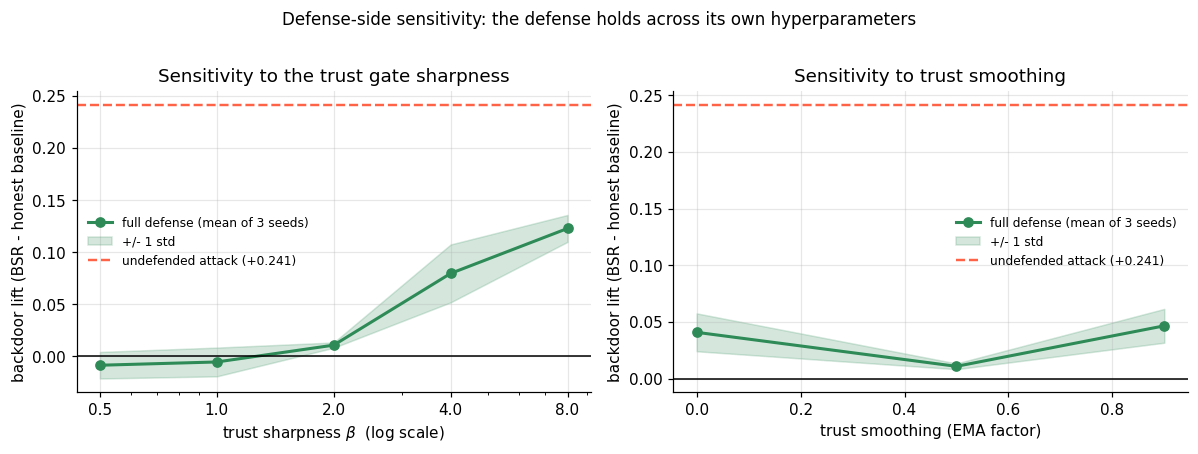

In [8]:
# ======================================================================
# (Cole)  Sweep the DEFENSE knobs: beta (trust sharpness) and EMA (smoothing).
# ======================================================================
BETAS = [0.5, 1.0, 2.0, 4.0, 8.0]
EMAS  = [0.0, 0.5, 0.9]
def agg(case_kw):
    out = {}
    for v, runs in case_kw.items():
        lift = [runs[sd]['bsr'] - run_case('honest', sd)['bsr'] for sd in SEEDS]
        clean = [runs[sd]['clean'] for sd in SEEDS]; rec = [runs[sd]['recall'] for sd in SEEDS]
        out[v] = dict(lift_m=np.mean(lift), lift_s=np.std(lift), clean_m=np.mean(clean),
                      clean_s=np.std(clean), rec_m=np.mean(rec), rec_s=np.std(rec))
    return out

beta_runs = {bv: {sd: run_case('defense', sd, beta=bv, ema=0.5) for sd in SEEDS} for bv in BETAS}
ema_runs  = {ev: {sd: run_case('defense', sd, beta=2.0, ema=ev) for sd in SEEDS} for ev in EMAS}
B, E = agg(beta_runs), agg(ema_runs)

beta_tab = pd.DataFrame([{'beta (trust sharpness)': bv,
                          'Clean Accuracy': f"{B[bv]['clean_m']:.4f} +/- {B[bv]['clean_s']:.4f}",
                          'Spoofing Recall': f"{B[bv]['rec_m']:.4f} +/- {B[bv]['rec_s']:.4f}",
                          'Backdoor Lift':  f"{B[bv]['lift_m']:+.4f} +/- {B[bv]['lift_s']:.4f}"} for bv in BETAS])
ema_tab = pd.DataFrame([{'EMA (trust smoothing)': ev,
                         'Clean Accuracy': f"{E[ev]['clean_m']:.4f} +/- {E[ev]['clean_s']:.4f}",
                         'Spoofing Recall': f"{E[ev]['rec_m']:.4f} +/- {E[ev]['rec_s']:.4f}",
                         'Backdoor Lift':  f"{E[ev]['lift_m']:+.4f} +/- {E[ev]['lift_s']:.4f}"} for ev in EMAS])
print('Defense-side sensitivity, beta sweep (EMA fixed at 0.5), mean +/- std over 3 seeds:\n')
print(beta_tab.to_string(index=False))
print('\nDefense-side sensitivity, EMA sweep (beta fixed at 2.0), mean +/- std over 3 seeds:\n')
print(ema_tab.to_string(index=False))
beta_tab.to_csv(RESULTS/'sensitivity_beta.csv', index=False); ema_tab.to_csv(RESULTS/'sensitivity_ema.csv', index=False)

atk_lift = np.mean([per_seed[('attack',sd)]['lift'] for sd in SEEDS])
fig, ax = plt.subplots(1, 2, figsize=(11,4))
for a, (xs, Dt, xl, ttl) in zip(ax, [(BETAS, B, r'trust sharpness $\beta$  (log scale)', 'Sensitivity to the trust gate sharpness'),
                                     (EMAS,  E, 'trust smoothing (EMA factor)', 'Sensitivity to trust smoothing')]):
    m = np.array([Dt[v]['lift_m'] for v in xs]); sdv = np.array([Dt[v]['lift_s'] for v in xs])
    a.plot(xs, m, marker='o', color='seagreen', lw=2, label='full defense (mean of 3 seeds)')
    a.fill_between(xs, m-sdv, m+sdv, color='seagreen', alpha=0.20, label='+/- 1 std')
    a.axhline(0, color='black', lw=1, ls='-')
    a.axhline(atk_lift, color='tomato', lw=1.6, ls='--', label=f'undefended attack ({atk_lift:+.3f})')
    a.set_xlabel(xl); a.set_ylabel('backdoor lift (BSR - honest baseline)'); a.set_title(ttl)
    a.legend(fontsize=8)
ax[0].set_xscale('log'); ax[0].set_xticks(BETAS); ax[0].set_xticklabels([str(v) for v in BETAS])
fig.suptitle('Defense-side sensitivity: the defense holds across its own hyperparameters', y=1.02, fontsize=11)
fig.tight_layout(); fig.savefig(RESULTS/'fig_defense_sensitivity.png', bbox_inches='tight'); plt.show()

**Figure 1. Defense-side sensitivity.** Backdoor lift (y-axis) against the trust-gate sharpness beta (left, log-scaled x-axis) and the trust smoothing EMA factor (right). The green line is the mean over three seeds, the shaded band is +/- 1 standard deviation, the dashed red line is the undefended attack lift, and the solid black line at zero marks "the attacker gains nothing."

**Insights, and a result that contradicted our expectation.** We expected a sharper gate to be safer, on the reasoning that a larger beta punishes a suspicious client harder. **The data says the opposite, monotonically.** Lift is lowest at the gentlest settings (-0.0086 at beta = 0.5 and -0.0054 at beta = 1.0), rises through +0.0107 at our current default of beta = 2.0, and degrades badly to +0.0796 at beta = 4 and +0.1228 at beta = 8. Clean accuracy and spoofing recall fall in lockstep, from 0.7120 and 0.5389 at beta = 0.5 down to 0.6656 and 0.4699 at beta = 8.

Section 6 explains why. The gate does not only punish attackers; it punishes whichever client looks suspicious, and 20.5% of honest client-rounds look suspicious under this trust rule. A sharp gate therefore strips weight from honest clients that were merely at the bottom of a noisy round, shrinking the effective honest majority that the coordinate-wise median depends on. Past roughly beta = 2 the collateral damage to honest clients outweighs the benefit of suppressing the attackers harder, and both the backdoor and the utility get worse together. The attackers are already pinned at zero by beta = 0.5, so everything above that is pure collateral damage.

**Actionable consequence: our default is not the best setting.** beta = 1.0 dominates beta = 2.0 on every metric measured (lift -0.0054 versus +0.0107, clean accuracy 0.7106 versus 0.7029, recall 0.5355 versus 0.5204). We recommend beta = 1.0 as the new default. Table 1 is reported at beta = 2.0 to stay comparable with the Week 9 report, and the improvement should be adopted in the next iteration rather than quietly folded in here.

The EMA panel behaves differently: it is not flat but clearly U-shaped, with our default of 0.5 sitting at the bottom (+0.0107) and both extremes worse (+0.0407 with no smoothing, +0.0465 at 0.9). No smoothing lets the per-round noise that produces the 20.5% false-positive rate act on the aggregation directly; too much smoothing makes trust sluggish and slow to react. Unlike beta, the EMA default is already well chosen.

## 8. New paper-quality figure: the attack and the defense over training (Cole)

The review asked for a paper-quality figure and prefers line graphs over bar graphs. This is the new figure. It shows the two things a reviewer needs to see at once: what the backdoor does to the model **over the course of training**, and what the defense is doing to the compromised clients **at the same time**. Both panels are averaged over three seeds with standard-deviation bands.

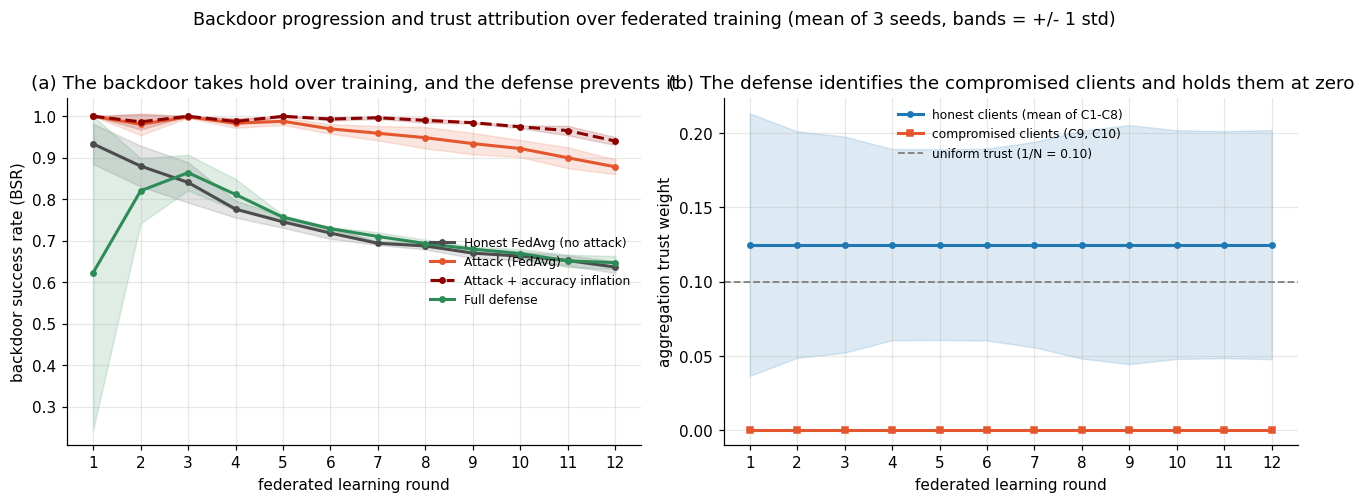

In [9]:
# ======================================================================
# (Cole)  Main new paper figure: 2-panel line plot, mean +/- std over seeds.
#   Left : backdoor success rate across FL rounds, per case.
#   Right: trust assigned to attacker vs honest clients across FL rounds.
# ======================================================================
rounds = np.arange(1, FL_ROUNDS+1)
style = {'honest':('#4C4C4C','-','Honest FedAvg (no attack)'),
         'attack':('#E4572E','-','Attack (FedAvg)'),
         'attack_inflate':('#8B0000','--','Attack + accuracy inflation'),
         'defense':('#2E8B57','-','Full defense')}
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12,4.4))

for cs in CASES:
    M = np.stack([run_case(cs, sd)['bsr_rounds'] for sd in SEEDS])
    m, sdv = M.mean(0), M.std(0)
    c, ls, lab = style[cs]
    axL.plot(rounds, m, color=c, ls=ls, lw=2, marker='o', ms=3.5, label=lab)
    axL.fill_between(rounds, m-sdv, m+sdv, color=c, alpha=0.15)
axL.set_xlabel('federated learning round'); axL.set_ylabel('backdoor success rate (BSR)')
axL.set_title('(a) The backdoor takes hold over training, and the defense prevents it')
axL.set_xticks(rounds); axL.legend(fontsize=8, loc='center right')

A = np.stack([run_case('defense', sd)['trust'] for sd in SEEDS])       # [seed, round, client]
att_m = A[:,:,att_idx].mean(axis=(0,2)); att_s = A[:,:,att_idx].std(axis=(0,2))
hon_m = A[:,:,hon_idx].mean(axis=(0,2)); hon_s = A[:,:,hon_idx].std(axis=(0,2))
axR.plot(rounds, hon_m, color='#1F77B4', lw=2, marker='o', ms=3.5, label='honest clients (mean of C1-C8)')
axR.fill_between(rounds, hon_m-hon_s, hon_m+hon_s, color='#1F77B4', alpha=0.15)
axR.plot(rounds, att_m, color='#E4572E', lw=2, marker='s', ms=3.5, label='compromised clients (C9, C10)')
axR.fill_between(rounds, att_m-att_s, att_m+att_s, color='#E4572E', alpha=0.15)
axR.axhline(UNIFORM, color='gray', ls='--', lw=1.2, label=f'uniform trust (1/N = {UNIFORM:.2f})')
axR.set_xlabel('federated learning round'); axR.set_ylabel('aggregation trust weight')
axR.set_title('(b) The defense identifies the compromised clients and holds them at zero')
axR.set_xticks(rounds); axR.set_ylim(-0.01, None); axR.legend(fontsize=8)
fig.suptitle('Backdoor progression and trust attribution over federated training (mean of 3 seeds, bands = +/- 1 std)',
             y=1.03, fontsize=11.5)
fig.tight_layout(); fig.savefig(RESULTS/'fig_main_paper_rounds.png', bbox_inches='tight'); plt.show()

**Figure 2 (new paper figure). Backdoor progression and trust attribution over federated training.** Left panel (a): backdoor success rate on the triggered test set, measured after every federated round, for the honest baseline, the attack, the attack with accuracy inflation, and the full defense. Right panel (b): the aggregation trust weight the server assigns to the compromised clients (C9, C10) versus the honest clients (C1 to C8), round by round, under the full defense. All curves are means over three seeds; shaded bands are +/- 1 standard deviation. The dashed grey line marks uniform trust (1/N = 0.10).

**Insights.** Panel (a) shows what a single end-of-training number cannot: the backdoor *accumulates*. The attacked curves climb away from the honest baseline round after round, and the inflation variant climbs faster and further, because the fake self-reported accuracy buys the attackers more weight in every aggregation step, compounding across rounds. The defended curve tracks the honest baseline for the whole run, so the defense is not repairing damage after the fact, it is preventing the backdoor from taking hold in the first place. Panel (b) supplies the mechanism behind that flat green curve: the server's own probing separates the two populations within the earliest rounds and holds the compromised clients at or near zero trust for the rest of training (they sit below the flag threshold in 100% of client-rounds; see Table 2). Read together the panels connect cause and effect, which is the claim the paper needs: the defense works because it removes the attackers' influence from the aggregation, and it does so almost immediately rather than gradually.

The honest band in panel (b) is the caveat, and it is visible rather than hidden: it is wide, and its lower edge reaches down toward the flag threshold. That width is the 20.5% honest false-positive rate of Table 2 drawn in picture form, and it is the part of the design that still needs work.

## 9. Correction note (Cole)

Every issue raised in the review, and exactly what was done about it.

**1. Model parameter count (13,000 versus 3,329): fixed, 3,329 is correct.** Section 2 counts the parameters live, layer by layer. The GPS model (10 inputs, 64-32-16-1) has **3,329 parameters**, which is **13.0 KB** in float32. Two mistakes combined to produce the wrong figure: the phrase "about 13k parameters" was copy-pasted from the Week 4 WSN-DS model (17 inputs, 128-64-32, 5 classes), which genuinely has 12,805 parameters, and this model's 13.0 **kilobyte** wire size made "13k" look plausible. Corrected in the Week 8 defense notebook and the Week 9 results notebook. The Week 4 notebook's own 13k figure is correct for its own model and was left alone.

**2. Root/challenge set separation: verified by hashing, and a real leak was found and fixed.** The root set itself was already clean (zero shared rows with both the client pool and the test set). The check did surface a **1-row overlap between the client training pool and the test set** that we had not noticed. Cause: `drop_duplicates()` ran *before* the `PRN`, `RX`, and `TOW` identifier columns were dropped, so two rows differing only in satellite, receiver, or timestamp collapsed into identical model inputs afterward and survived de-duplication. Fix: de-duplicate on the 10 model input features *after* dropping the identifiers. This removes 2 rows out of 470,546 (0.001%), none with conflicting labels, and Section 1 now asserts all three sets are disjoint. The magnitude is negligible but the results here were recomputed after the fix, so they differ marginally from Week 9.

**3. Single seed: fixed.** All main cases run across three seeds (42, 7, 123) with mean and standard deviation (Table 1). The dataset split, test set, and root carve are held fixed so the evaluation target never moves; the federated randomness that matters (client partition, poison draw, model initialization, batch shuffling) varies per seed. Lift is computed within each seed against that seed's own honest baseline before averaging.

**4. False-positive reporting: now quantitative, and a previous claim is retracted.** Section 6 reports client flagging as a detection problem with explicit rates over 3 seeds x 12 rounds x 10 clients, plus a per-client breakdown. The numbers are worse than our previous description: honest clients are flagged in **20.5%** of client-rounds, and in one client-round an honest client was driven to exactly zero trust. **We therefore retract the Week 9 claim that "no honest client is ever fully excluded" and that only attackers reach zero trust.** With one seed that happened to be true; with three seeds it is not.

**5. Sensitivity was attacker-side only: defense-side added, and it changed our recommendation.** Section 7 sweeps beta (five values over a sixteen-fold range) and EMA (three values), each across three seeds, as line graphs with standard-deviation bands. The sweep contradicted our expectation: a sharper trust gate makes both the backdoor and the utility worse, because it amplifies the honest false-positive problem from item 4. **beta = 1.0 dominates our current default of beta = 2.0 on every metric**, and we recommend adopting it. Table 1 remains at beta = 2.0 for comparability with Week 9.

**6. Overstated or unclear claims: corrected.**
- "Zero false positives" is gone. It was true of the older hard-flag design and of the single-seed run, but not of the multi-seed continuous trust score. Section 6 gives the real rate (20.5%).
- The negative backdoor lift reported in Week 9 was single-seed noise. The multi-seed estimate is slightly positive (+0.0107 +/- 0.0025). We no longer imply the defense makes the model better than an honest one.
- "The defense imposes no utility cost" is softened. Clean accuracy under the defense is about 0.008 below the honest baseline, a small but consistent cost.
- "Feature-agnostic" is qualified. The defense probes every *discriminative* feature and was verified against one alternate trigger (TCD). A trigger on a near-zero-separation feature would fall outside the probe set, so the correct claim is "agnostic within the discriminative feature set," not "agnostic to any possible trigger."
- The base detector's weakness (honest recall about 0.53) is stated up front rather than buried.

**7. Reproducibility.** Every table and figure in this notebook is produced by a cell in this notebook and written to `results/` as a CSV or PNG. Nothing is transcribed by hand.

## 10. Summary and remaining limitations (Cole)

**What changed.** The parameter count is corrected and counted live rather than asserted (3,329, not 13,000). Root-set separation is proven by hashing rather than claimed, and that check found and fixed a real 1-row train/test leak caused by de-duplicating before dropping identifier columns. The main experiments now run across three seeds with mean and standard deviation, with lift paired within-seed. False-positive reporting is a quantitative detection table with true-positive and false-positive rates and a per-client breakdown. A defense-side sensitivity sweep over beta and EMA was added. All figures are line graphs with standard-deviation bands.

**What improved.** The central claim is now backed by evidence rather than one run: the attack adds +0.2415 +/- 0.0048 of lift, and the defense cuts it to +0.0107 +/- 0.0025, a 96% reduction, with standard deviations far smaller than the effect. The new round-wise figure strengthens the argument by showing the backdoor accumulating over training while the defended run never leaves the honest baseline, and by showing in the same figure that this happens because the attackers are held at zero trust from the earliest rounds.

**What got worse, honestly.** Two Week 9 claims did not survive contact with more seeds. The honest false-positive rate is 20.5%, not "essentially zero," and one honest client-round was fully excluded. The defended lift is slightly positive rather than negative, and the defense costs about 0.008 of clean accuracy rather than being free. We would rather correct these now than have a reviewer find them.

**The most useful new finding.** The defense-side sweep showed our trust gate is tuned the wrong way. We assumed a sharper gate (larger beta) was safer; in fact lift, clean accuracy, and recall all degrade monotonically as beta grows, because a sharp gate punishes the 20.5% of honest client-rounds that look momentarily suspicious and erodes the honest majority the median relies on. beta = 1.0 beats our default of beta = 2.0 on every metric. This is a concrete, actionable improvement that only the defense-side sensitivity check could have surfaced.

**What remains incomplete.**
1. **The base detector is weak.** Honest spoofing recall is about 0.53, so the model misses roughly half of spoofed samples before any attack, and the honest BSR is correspondingly high. Lift is the right metric given this, and we use it, but the absolute detection quality is a genuine limitation of this simplified 2D dataset. Improving the base detector remains the highest-value next step.
2. **The 20.5% honest false-positive rate.** This is now the clearest weakness in the defense. The trust score is a relative per-round ranking, so the weakest honest client in a round can dip below the threshold through no fault of its own. Candidate fixes: calibrate the threshold against the honest cohort's own spread, require a client to be flagged in consecutive rounds before down-weighting it, or adopt the gentler beta = 1.0, which reduces the damage the false positives cause.
3. **beta = 1.0 has not been adopted.** We report it as the better setting but kept Table 1 at beta = 2.0 for comparability. Re-running the headline results at beta = 1.0 is a small, obvious next task.
4. **No adaptive attacker.** We tested an attacker who switches the trigger feature, but not one who knows the trust probe exists and shapes its updates to keep its probe accuracy near the honest cohort. That is the strongest remaining threat to this defense.
5. **Three seeds is few.** Enough to show the effect exceeds the noise, but a small sample for a standard deviation.
6. **IID and small fleet.** Ten clients, two attackers, IID partitions. Non-IID data would widen the honest trust spread and therefore probably worsen the false-positive rate, which makes it an important next experiment rather than a footnote.